In [42]:

import math
from collections.abc import Sequence
from functools import lru_cache
from itertools import product

import matplotlib.pyplot as plt

from 信用交易所模型 import 信用交易所, 信用交易所商品
from 中间结果.不同购买策略的比较 import 不同购买策略的比较

plt.rcParams['font.family'] = "serif"
plt.rcParams['font.serif'] = ["CMU Serif", "Source Han Serif SC"]
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams["axes.titleweight"] = "bold"

In [49]:
最优购买策略 = 不同购买策略的比较["考虑天数为 N = 11 时的信用交易所最优购买策略"]
从左到右购买策略 = 不同购买策略的比较["从左到右购买，直到不能购买为止策略"]
按性价比从高到低购买策略 = 不同购买策略的比较["按性价比从高到低购买，直到不能购买为止策略"]
性价比加阈值策略 = 不同购买策略的比较["按性价比从高到低购买，并设定性价比阈值策略"]
每日多获得的129信用的价值 = 最优购买策略(942) - 最优购买策略(813)
从左到右购买策略的表现 = 从左到右购买策略(813) / 最优购买策略(813)
按性价比从高到低购买策略的表现 = 按性价比从高到低购买策略(813) / 最优购买策略(813)
性价比加阈值策略的表现 = 性价比加阈值策略(813) / 最优购买策略(813)
print(f"3 发电站基建布局比 2 发电站基建布局每日多获得的 129 信用大约相当于 {每日多获得的129信用的价值:.4f} 理智。")
print(f"“从左到右购买，直到不能购买为止”策略的表现只有最优策略的 {从左到右购买策略的表现:.4%} 左右。")
print(f"“按性价比从高到低购买，直到不能购买为止”策略的表现可以达到最优策略的 {按性价比从高到低购买策略的表现:.4%} 左右。")
print(f"“按性价比从高到低购买，并设定性价比阈值”策略的表现可以进一步达到最优策略的 {性价比加阈值策略的表现:.4%} 左右。")

3 发电站基建布局比 2 发电站基建布局每日多获得的 129 信用大约相当于 5.2206 理智。
“从左到右购买，直到不能购买为止”策略的表现只有最优策略的 86.4615% 左右。
“按性价比从高到低购买，直到不能购买为止”策略的表现可以达到最优策略的 98.6074% 左右。
“按性价比从高到低购买，并设定性价比阈值”策略的表现可以进一步达到最优策略的 99.9383% 左右。


## 最优策略不稳定的例子

In [25]:
# 最优策略不稳定的例子

@lru_cache(maxsize=None)
def 计算总价格(购买指标向量: Sequence[bool]) -> int:
    return sum(商品.现价 for i, 商品 in enumerate(商店.商品列表) if 购买指标向量[i])


@lru_cache(maxsize=None)
def 计算总价值(购买指标向量: Sequence[bool]) -> float:
    return sum(商品.价值 for i, 商品 in enumerate(商店.商品列表) if 购买指标向量[i])


def 求解单个商店最优购买策略(当前信用: int, K_n_C_x: list[float]) -> tuple[float, tuple[bool, ...]]:
    """在 2**10 种购买方案中选一种不超支的，使得 当天购买的物品总价值 + K_n_C_x[能够继承的信用] 最大"""
    目标函数最大值: float = -math.inf
    最优策略购买指标向量: tuple[bool, ...] = tuple(False for _ in range(len(商店.商品列表)))
    for 购买指标向量 in product((False, True), repeat=len(商店.商品列表)):  # 枚举 2 ** 10 种购买方案
        总价格: int = 计算总价格(购买指标向量)
        总价值: float = 计算总价值(购买指标向量)
        if 总价格 <= 当前信用:
            剩余信用: int = 当前信用 - 总价格
            能够继承的信用: int = min(剩余信用, 300)
            目标函数: float = 总价值 + K_n_C_x[能够继承的信用]
            if 目标函数 > 目标函数最大值:
                目标函数最大值 = 目标函数
                最优策略购买指标向量 = 购买指标向量

    return 目标函数最大值, 最优策略购买指标向量


def 标准化(K_n_C_x: list[float]) -> list[float]:
    """将 K_n_C_x 标准化到 [0, 1]"""
    return [K_n_C_x[c] - K_n_C_x[0] for c in range(301)]


# 模拟购买的商店
# 商店 = 信用交易所(剩余信用=0, 商品列表=[
#     信用交易所商品(商品名称="破损装置×2", 折扣=75, 已购买=False),
#     信用交易所商品(商品名称="赤金×6", 折扣=75, 已购买=False),
#     信用交易所商品(商品名称="糖×2", 折扣=50, 已购买=False),
#     信用交易所商品(商品名称="源岩×2", 折扣=50, 已购买=False),
#     信用交易所商品(商品名称="酮凝集×2", 折扣=50, 已购买=False),
#     信用交易所商品(商品名称="糖×2", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="龙门币×3600", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="初级作战记录×9", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="初级作战记录×9", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="招聘许可×1", 折扣=0, 已购买=False),
# ])


# 不稳定的商店
商店 = 信用交易所(剩余信用=0, 商品列表=[
    信用交易所商品(商品名称="糖×2", 折扣=75, 已购买=False),
    信用交易所商品(商品名称="酮凝集×2", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="糖×2", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="碳素×3", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="基础作战记录×9", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="家具零件×25", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="招聘许可×1", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="招聘许可×1", 折扣=0, 已购买=False),
    信用交易所商品(商品名称="家具零件×20", 折扣=0, 已购买=False),
    信用交易所商品(商品名称="装置×1", 折扣=0, 已购买=False),
])


每日获得的信用C = 813
考虑的天数N = 41

K_0_C_x: list[float] = [0 for _ in range(301)]
K_x_C_x: list[list[float]] = [K_0_C_x]

for n in range(1, 考虑的天数N):
    K_n减1_C_x: list[float] = K_x_C_x[-1]
    K_n_C_x: list[float] = [0 for _ in range(301)]
    for 继承的信用c in range(301):
        目标函数最大值, _ = 求解单个商店最优购买策略(继承的信用c + 每日获得的信用C, K_n减1_C_x)
        K_n_C_x[继承的信用c] = 目标函数最大值
        # print(f'K_{n}_{每日获得的信用C}_{继承的信用c} = {K_n_C_x[继承的信用c]}')
    K_x_C_x.append(K_n_C_x)

# for n, K_n_C_x in enumerate(K_x_C_x):
#     print(f'K_{n}_{每日获得的信用C}_x: {K_n_C_x}')


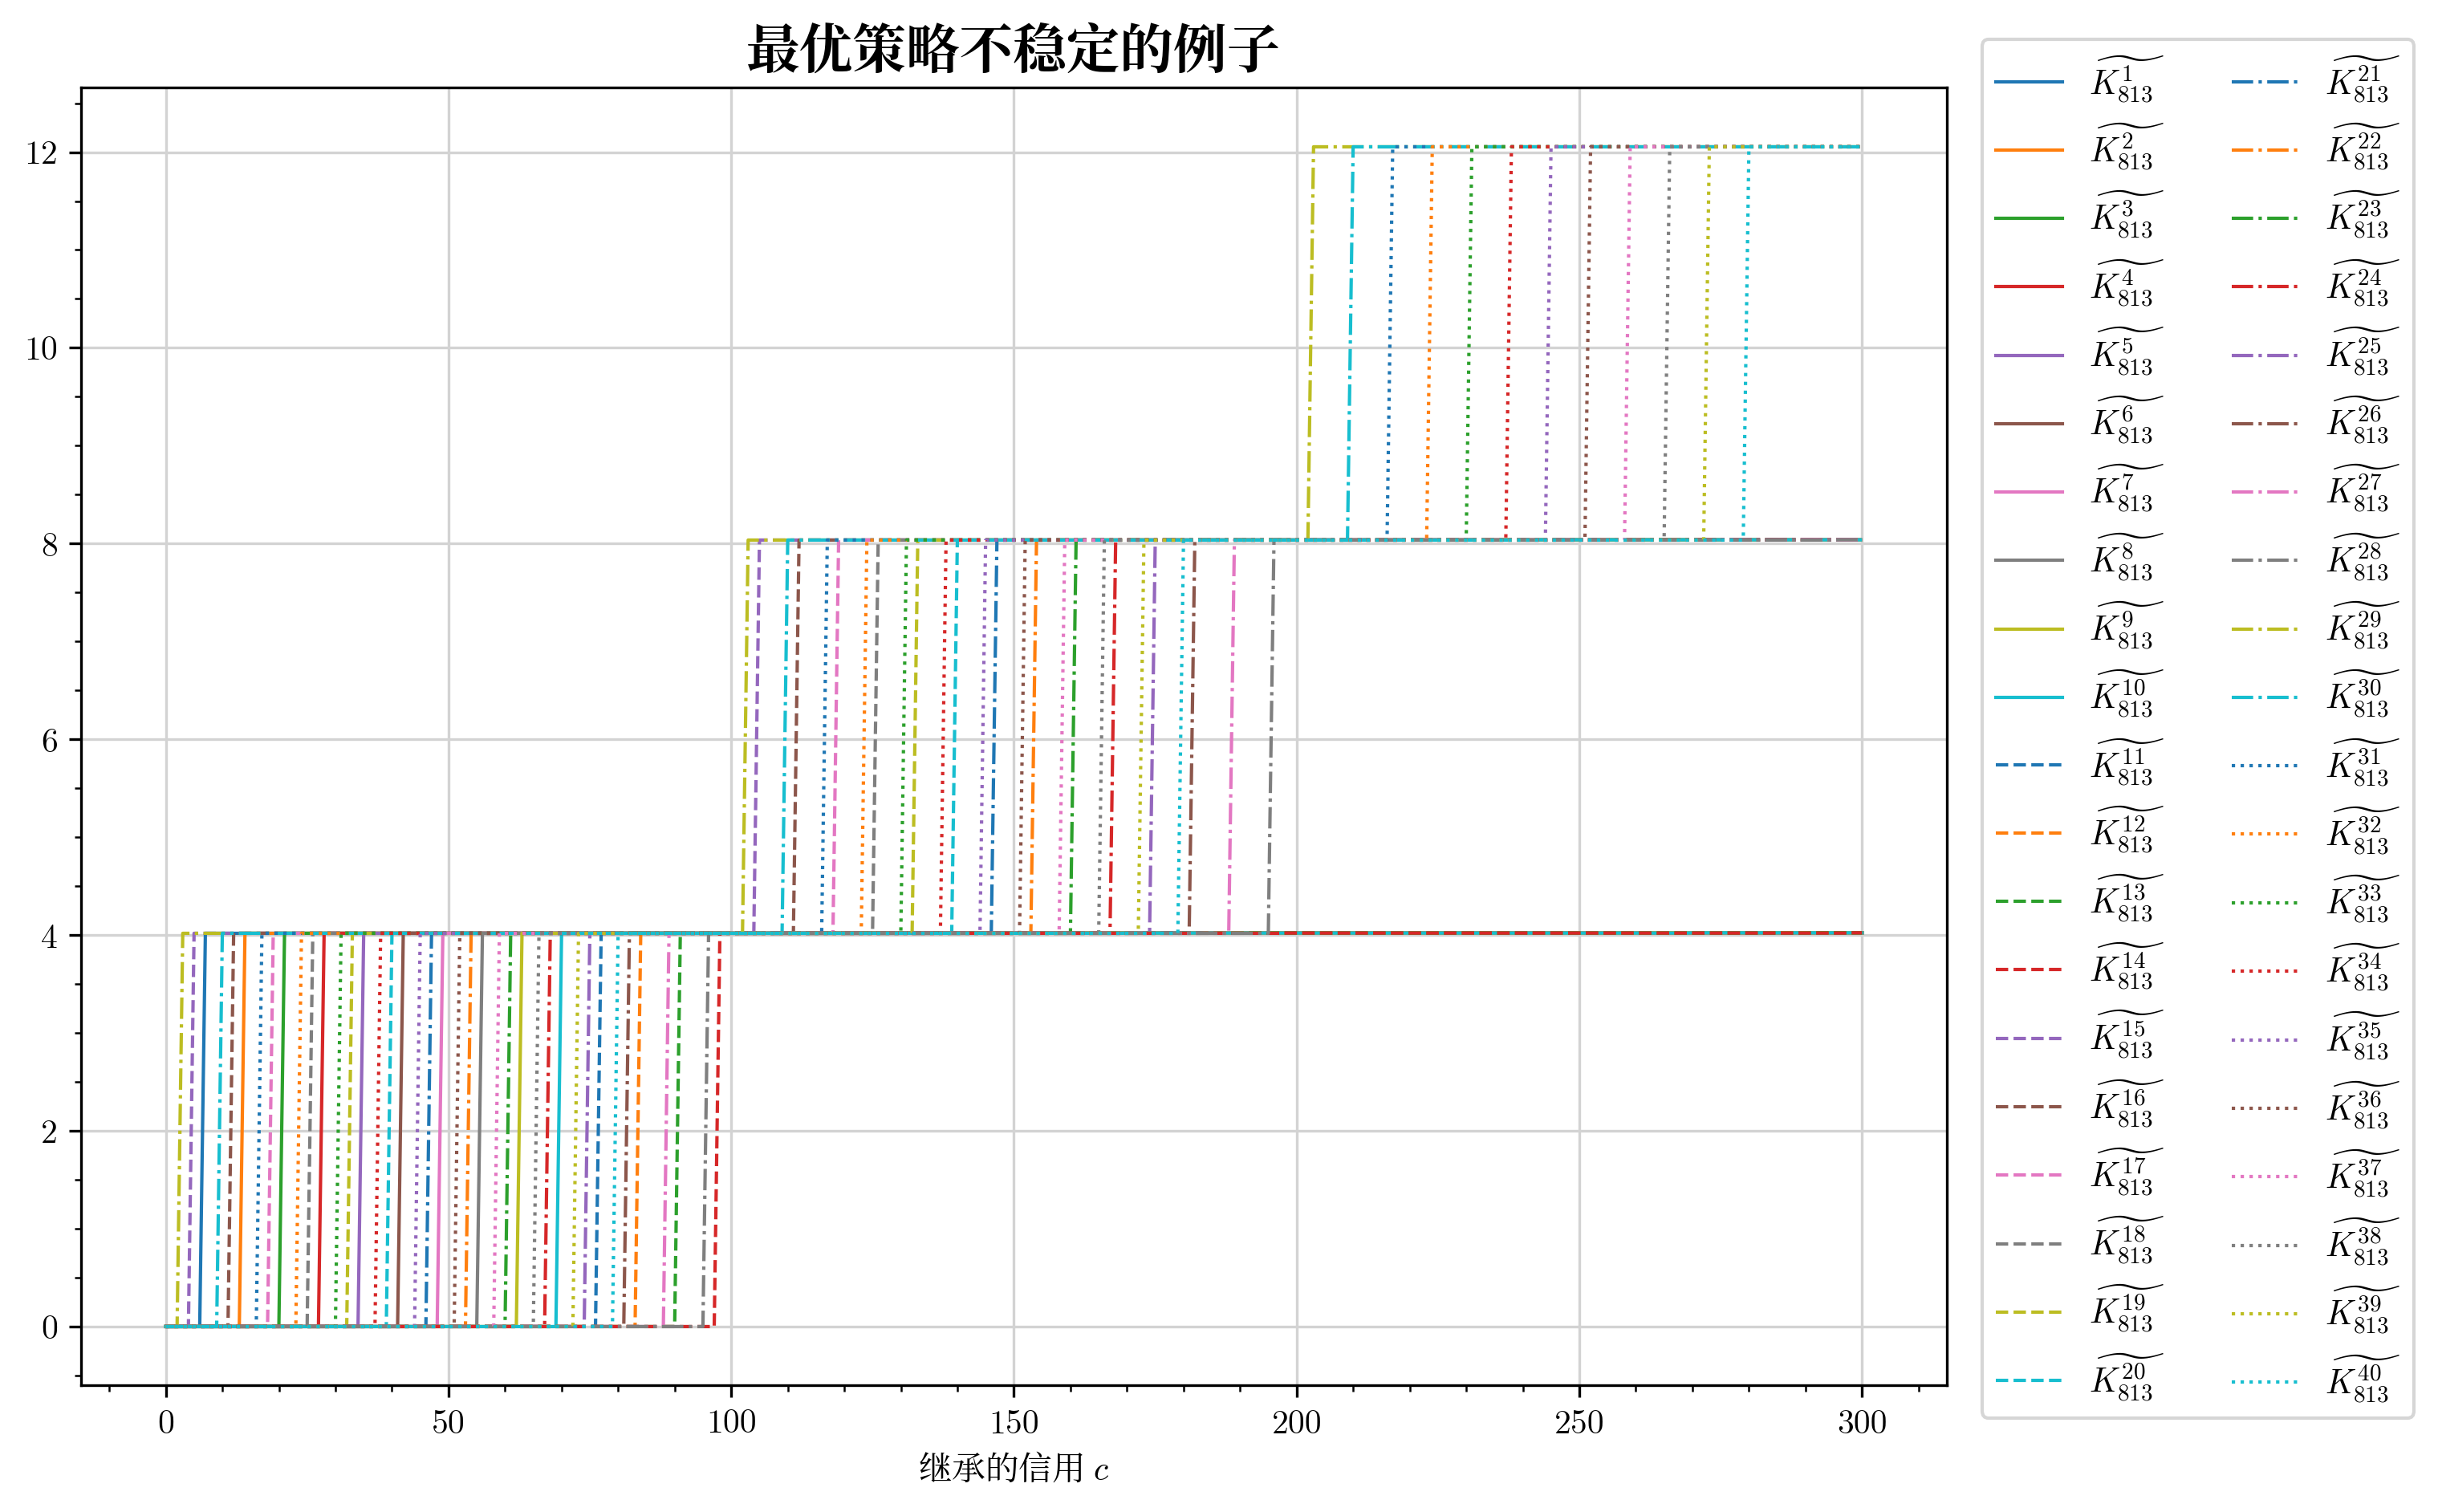

In [40]:
plt.figure()
for n, K_n_C_x in enumerate(K_x_C_x):
    if n == 0:
        continue
    标准化的K_n_C_x = 标准化(K_n_C_x)
    if 0 < n <= 10:
        linestyle = '-'
    elif 10 < n <= 20:
        linestyle = '--'
    elif 20 < n <= 30:
        linestyle = '-.'
    else:
        linestyle = ':'
    plt.plot(range(301), 标准化的K_n_C_x, linestyle=linestyle, linewidth=1, label=r'$\widetilde{K^{%d}_{813}}$' % n)
plt.title("最优策略不稳定的例子", fontsize=16, family=["Source Han Serif SC"])
plt.xlabel("继承的信用 $c$", family=["Source Han Serif SC"])
plt.legend(ncol=2, bbox_to_anchor=(1.01, 1.05), loc='upper left')
plt.minorticks_on()
plt.grid(color='lightgray', which='major')